In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from scipy.constants import elementary_charge, Boltzmann

In [2]:
# Constantes necesarias

# Hz,  el valor de 1/t_0
t_0 = 10**13

# eV
E_a = 1

# Tiene distintos valores dependiendo si el estado es FORMING/SET y RESET
gamma = 3

# Valor de la constante de Boltzmann en eV/K
k_b_ev = Boltzmann / elementary_charge

# Factor de recombinación debido a la presencia de exceso de iones de oxígeno
beta_0 = 3e3

# Potencial de migración de los iones de oxígeno en eV
E_m = 1.0

# Coeficiente de deriva de los iones de oxígeno debido a la presencia de un campo eléctrico externo
gamma_drift = 8

# m, longitud de decaimiento de la concentración de oxígeno
L_p = 1e-9

In [3]:
def DifussiveBehaviour(pos_x: int, Oxigen_Ion_velocity: float, Simulation_time: float, grid_size: float = 0.25e-9) -> float:
    """
    Calculates the diffusion behavior based on the given parameters.

    Parameters:
    - pos_x (int): The position of the diffusion event.
    - Oxigen_Ion_velocity (float): The velocity of the oxygen ion.
    - Simulation_time (float): The simulation time.
    - grid_size (float, optional): The size of the grid. Default is 0.25e-9.

    Returns:
    - float: The diffusion value based on the given conditions.
    """

    vt = Oxigen_Ion_velocity*Simulation_time
    pos_x = pos_x*grid_size

    condiciones = [pos_x <= vt,
                   (vt < pos_x) and (pos_x <= vt + grid_size),
                   (vt + grid_size < pos_x) and (pos_x <= vt + 3*grid_size),
                   (pos_x > vt + 3*grid_size)
                   ]

    valores_Difusion = [1, 0.3, 0.1, 0]

    return np.piecewise(pos_x, condiciones, valores_Difusion)

In [4]:
def recombination(simulation_time: float, pos_x: float, electric_field: float, temperature: float, grid_size=0.25e-9):

    Oxigen_Ion_velocity = beta_0 * grid_size * \
        math.exp(-E_m / (k_b_ev * temperature)) * \
        math.sinh((2*elementary_charge * grid_size * electric_field * gamma_drift) /
                  (k_b_ev * temperature))

    Prob_in_equilibrio = (simulation_time * t_0) / \
        (math.exp(-E_a /
                  (k_b_ev * temperature)))

    Recombination_Probability = beta_0 * (
        math.exp(-simulation_time * Oxigen_Ion_velocity / L_p)) * \
        DifussiveBehaviour(pos_x, Oxigen_Ion_velocity, simulation_time, grid_size)

    return Prob_in_equilibrio * Recombination_Probability

In [5]:
# Creo vectores para el campo eléctrico, temperatura y tiempo de simulación.

potencial = np.linspace(0, 10, 100)
electric_field = potencial/(10e-9)

temperature = np.linspace(300, 400, 100)
simulation_time = np.linspace(0, 1, 100)

pos_x = np.linspace(0, 10, 41)

ValueError: too many values to unpack (expected 2)

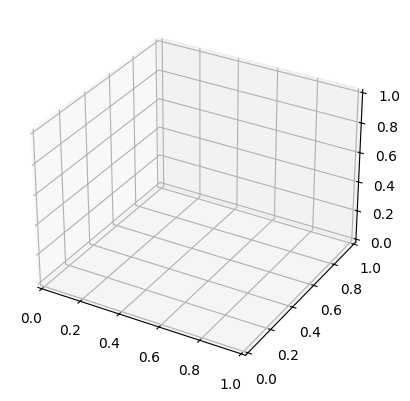

In [6]:
# represento la probabilidad de generación en función del campo eléctrico y la temperatura

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

X, Y = np.meshgrid(electric_field, np.linspace(0, 10e-9, 41), temperature)
Z = np.zeros((len(electric_field), len(temperature)))

ax.plot_surface(X, Y, Z)

plt.show()

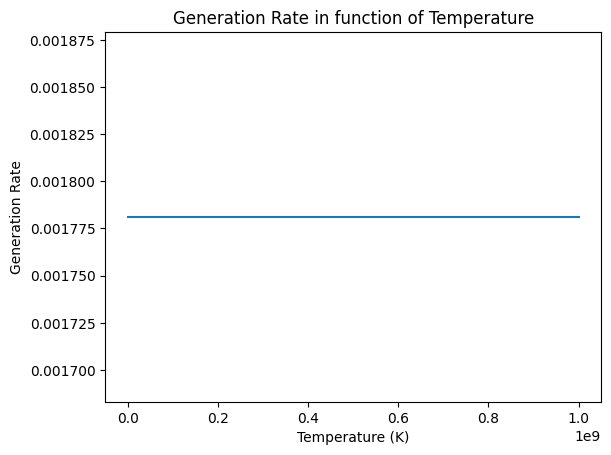

In [ ]:
# represento la probabilidad de generación en función de la temperatura en dos dimensiones

fig, ax = plt.subplots()

ax.plot(electric_field, (1, electric_field, 320))
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Generation Rate')
ax.set_title('Generation Rate in function of Temperature')

plt.show()

832.6138471369986
